In [55]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# import my personal plotting config
import matplotlib as mpl
mpl_config = {'figure.figsize': (12, 6),
              'savefig.dpi': 300,
              'figure.dpi': 150,
              'font.family': 'serif',
              'font.serif': ['Computer Modern'],
              'text.usetex': True,
              'font.size': 11,
              'axes.labelsize': 10,
              'axes.titlesize': 12,
              'xtick.labelsize': 9,
              'ytick.labelsize': 9,
              'legend.fontsize': 10,
              'lines.linewidth': 2,
              'axes.linewidth': 0.8,
              'savefig.bbox': 'tight'}

mpl.rcParams.update(mpl_config)

In [ ]:
# DATA

# feature_names=["isthmuscingulate", "precuneus"] # original names
feature_names = ["IC", "PC"]  # short hands


# train sets
train_sNC = pd.read_csv("train.sNC.csv", names=feature_names)
train_sDAT = pd.read_csv("train.sDAT.csv", names=feature_names)

# test sets
test_sNC = pd.read_csv("test.sNC.csv", names=feature_names)
test_sDAT = pd.read_csv("test.sDAT.csv", names=feature_names)

# 2D grid points
axis_names = ["x", "y"]
grid = pd.read_csv("2D_grid_points.csv", names=axis_names)
grid_sNC = pd.read_csv("2D_grid_points.sNC.csv", names=axis_names)
grid_sDAT = pd.read_csv("2D_grid_points.sDAT.csv", names=axis_names)

In [58]:
train_sNC.head()

,IC,PC
0,1.366587,1.490817
1,1.451712,1.719282
2,1.551907,1.737187
3,1.646538,1.774696
4,1.423163,1.563309


In [59]:
print(f"Shape of train set sNC = {train_sNC.shape}")
print(f"Shape of train set sDAT = {train_sDAT.shape}\n")

print(f"Shape of test set sNC = {test_sNC.shape}")
print(f"Shape of test set sDAT = {test_sDAT.shape}")

Shape of train set sNC = (237, 2)
Shape of train set sDAT = (237, 2)

Shape of test set sNC = (100, 2)
Shape of test set sDAT = (100, 2)


In [60]:
print(f"Shape of grid points = {grid.shape}")
print(f"Shape of grid sNC = {grid_sNC.shape}")
print(f"Shape of grid sDAT = {grid_sDAT.shape}")

Shape of grid points = (1225, 2)
Shape of grid sNC = (595, 2)
Shape of grid sDAT = (630, 2)


Text(0, 0.5, '$x_2$')

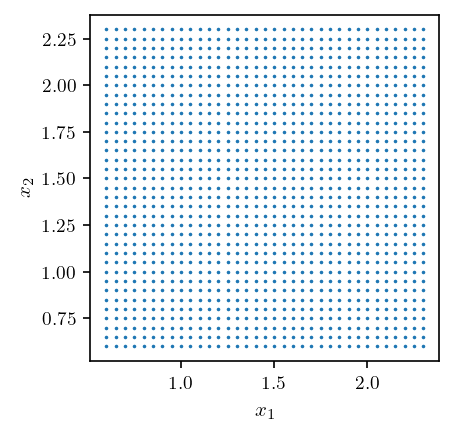

In [61]:
plt.figure(figsize=(3, 3))

plt.axis("equal")
plt.scatter(grid.x, grid.y, s=0.5)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

Text(0, 0.5, '$x_2$')

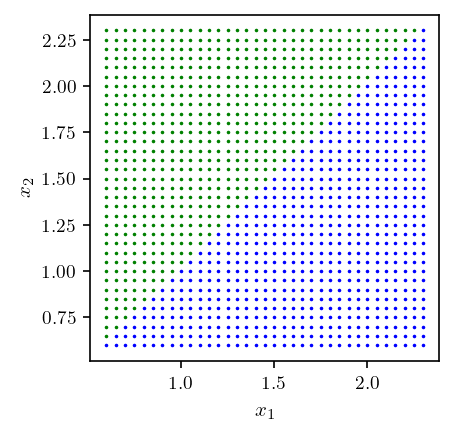

In [62]:
plt.figure(figsize=(3, 3))
plt.scatter(grid_sNC.x, grid_sNC.y, s=0.5, c="g")
plt.scatter(grid_sDAT.x, grid_sDAT.y, s=0.5, c="b")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

In [63]:
# Set all sNC to label "0" = green
ytrain_sNC = pd.DataFrame({"y": [0] * len(train_sNC)})
ytest_sNC = pd.DataFrame({"y": [0] * len(test_sNC)})
print("sNC train target", ytrain_sNC.shape)
print("sNC test target", ytest_sNC.shape, "\n")

# Set all sDAT to label "1" = blue
ytrain_sDAT = pd.DataFrame({"y": [1] * len(train_sDAT)})
ytest_sDAT = pd.DataFrame({"y": [1] * len(test_sDAT)})
print("sDAT train target", ytrain_sDAT.shape)
print("sDAT test target", ytest_sDAT.shape)

sNC train target (237, 1)
sNC test target (100, 1) 

sDAT train target (237, 1)
sDAT test target (100, 1)


In [64]:
# Concat train
X_train = pd.concat([train_sDAT, train_sNC], ignore_index=True)
y_train = pd.concat([ytrain_sDAT, ytrain_sNC], ignore_index=True)

# Concat test
X_test = pd.concat([test_sDAT, test_sNC], ignore_index=True)
y_test = pd.concat([ytest_sDAT, ytest_sNC], ignore_index=True)

In [65]:
# mark train with "o"
# mark test with "+"
# mark grid points with "."

### Question 1

- Train kNN classifiers using the Euclidean distance metric and setting k = 1, 3, 5, 10, 20, 30, 50, 100, 150, 200 respectively. 
- Generate classification boundary visualization plots similar to Figure 2 for each of the trained classifiers. 
  - However, your plots should also contain an overlay of the training and test dataset samples colored based on their true class labels. 
  - In the plot title, report the error rates achieved on the training and test datasets respectively. 
- Discuss the classification performance of the classifiers trained for various “k” values in the context of over(under)fitting, bias and variance.

In [66]:
# sklearn training
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [67]:
def f_prime(x1, x2):
    if x1 <= x2:
        return 0
    else:
        return 1

In [ ]:
def train_knn(k, X_train, y_train, X_test, y_test, grid):
    # Build pipeline
    pipe = Pipeline(steps=[
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
    ])

    # Fit model
    pipe.fit(X=X_train, y=y_train.values.flatten())

    # predictions
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    # Decision boundary grid
    grid_db = grid.copy()
    grid_db.columns = X_train.columns
    grid_pred = pipe.predict(grid_db)

    # Errors calculation
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    print(f"k={k}, Train error={train_error:.4f}, Test error={test_error:.4f}")

    # Plot
    plt.figure(figsize=(8, 8))
    # def color_map(label): return 'green' if label == 0 else 'blue'

    # Decision boundary
    colors_grid = np.array(['green', 'blue'])
    plt.scatter(grid_db['IC'], grid_db['PC'], c=colors_grid[grid_pred],
                marker='.', s=1, alpha=0.3)

    # Training data - split by class
    y_train_flat = y_train.values.flatten()
    plt.scatter(X_train[y_train_flat == 0]['IC'], X_train[y_train_flat == 0]['PC'],
                c='green', marker='o', s=50, edgecolors='black',
                linewidths=0.5, label='sNC (0)')
    plt.scatter(X_train[y_train_flat == 1]['IC'], X_train[y_train_flat == 1]['PC'],
                c='blue', marker='o', s=50, edgecolors='black',
                linewidths=0.5, label='sDAT (1)')

    # Test data - split by class (no legend, same colors)
    y_test_flat = y_test.values.flatten()
    plt.scatter(X_test[y_test_flat == 0]['IC'], X_test[y_test_flat == 0]['PC'],
                c='green', marker='+', s=100, linewidths=2)
    plt.scatter(X_test[y_test_flat == 1]['IC'], X_test[y_test_flat == 1]['PC'],
                c='blue', marker='+', s=100, linewidths=2)

    plt.xlabel(r"$x_1$ (Isthmuscingulate)")
    plt.ylabel(r"$x_2$ (Precuneus)")
    plt.legend(loc='lower right')
    plt.title(
        f'k={k}: Train Error={train_error:.4f}, Test Error={test_error:.4f}')
    plt.savefig(f'q1/q1_k{k}.pdf')

    plt.show()

    return pipe, train_error, test_error

k=1, Train error=0.0000, Test error=0.2250


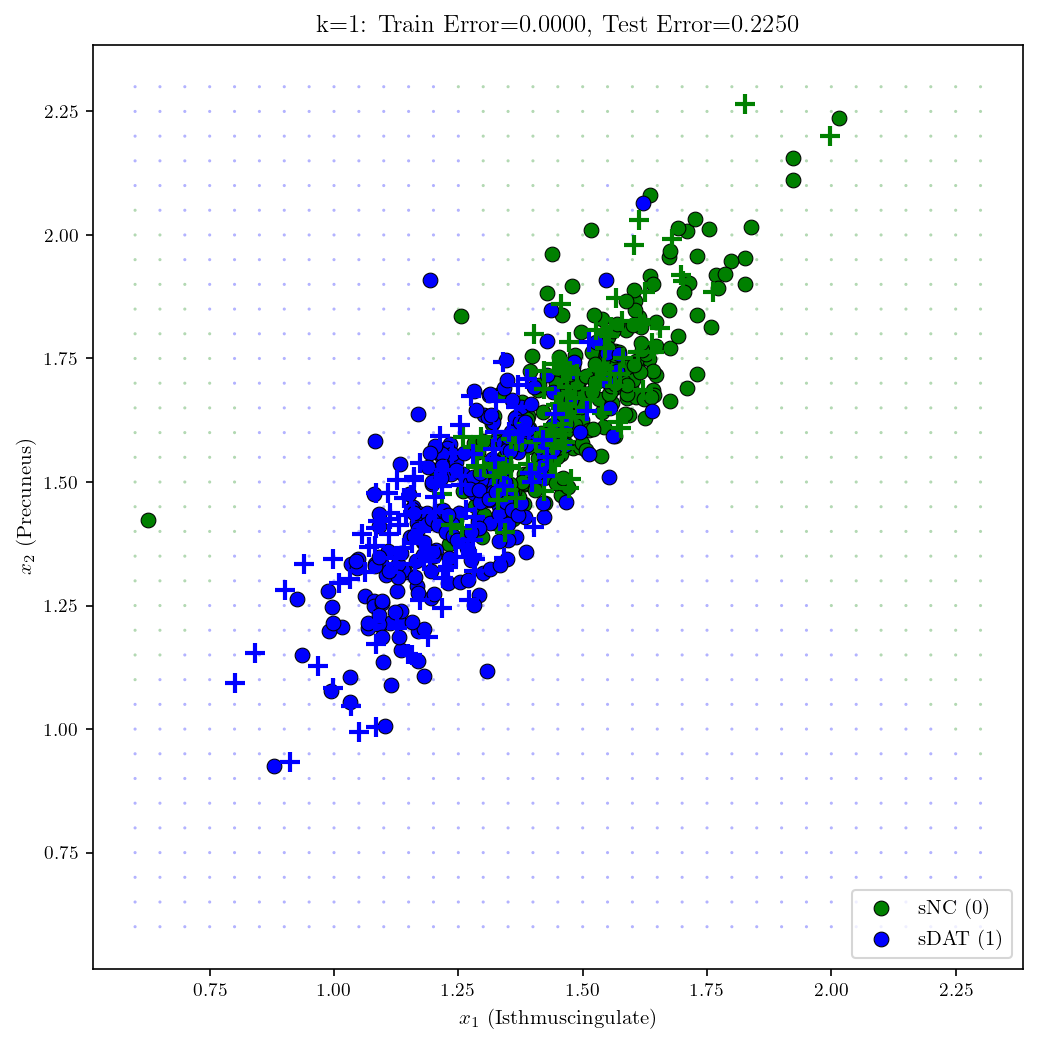

k=3, Train error=0.1456, Test error=0.2100


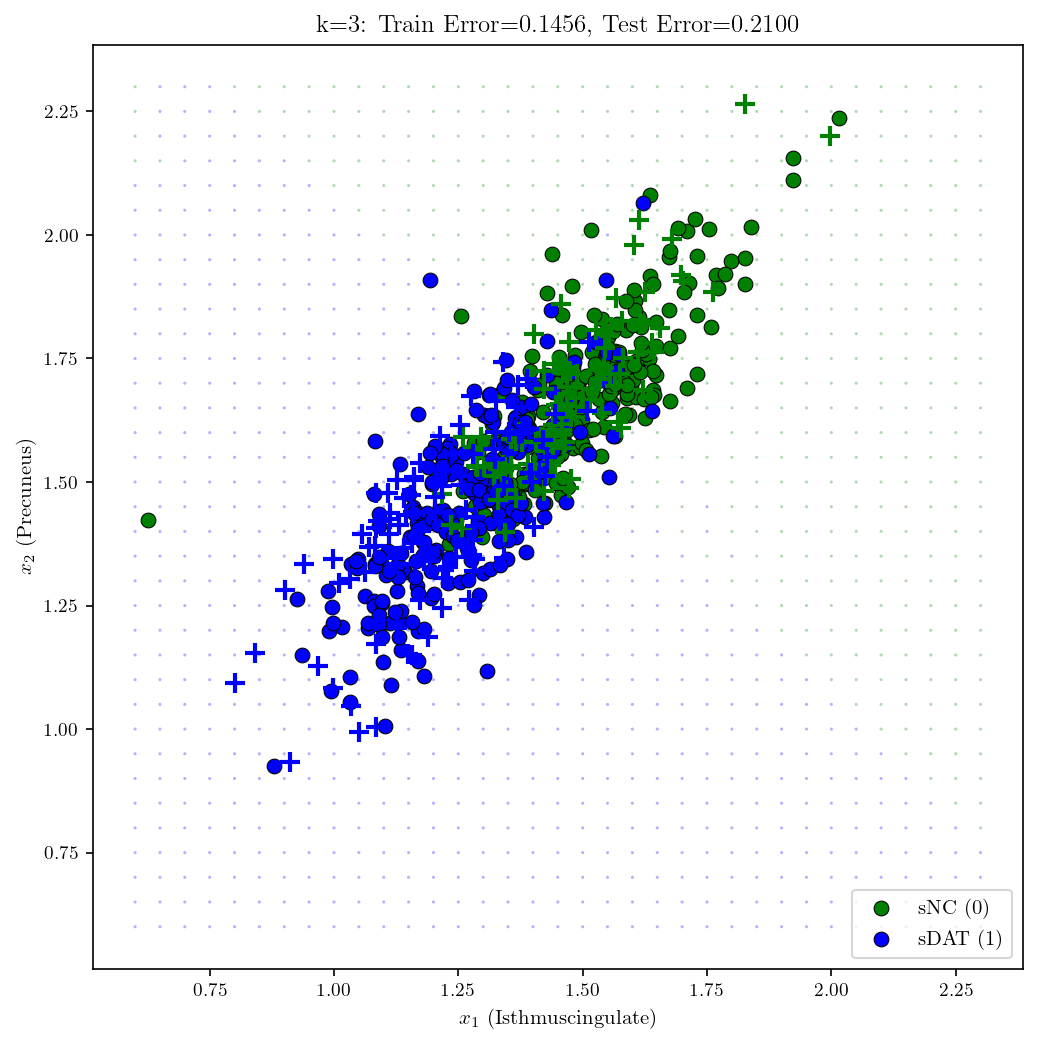

k=5, Train error=0.1603, Test error=0.1600


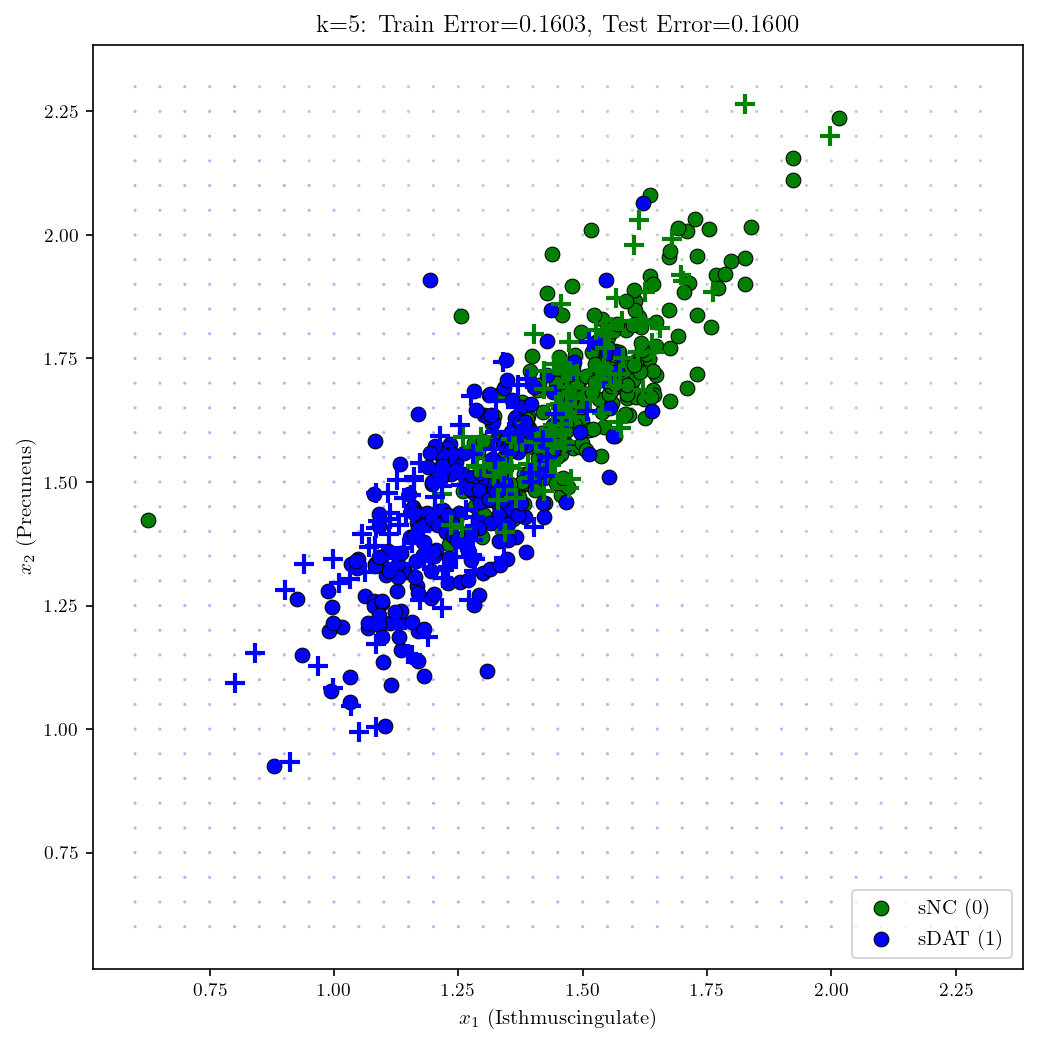

k=10, Train error=0.1561, Test error=0.1750


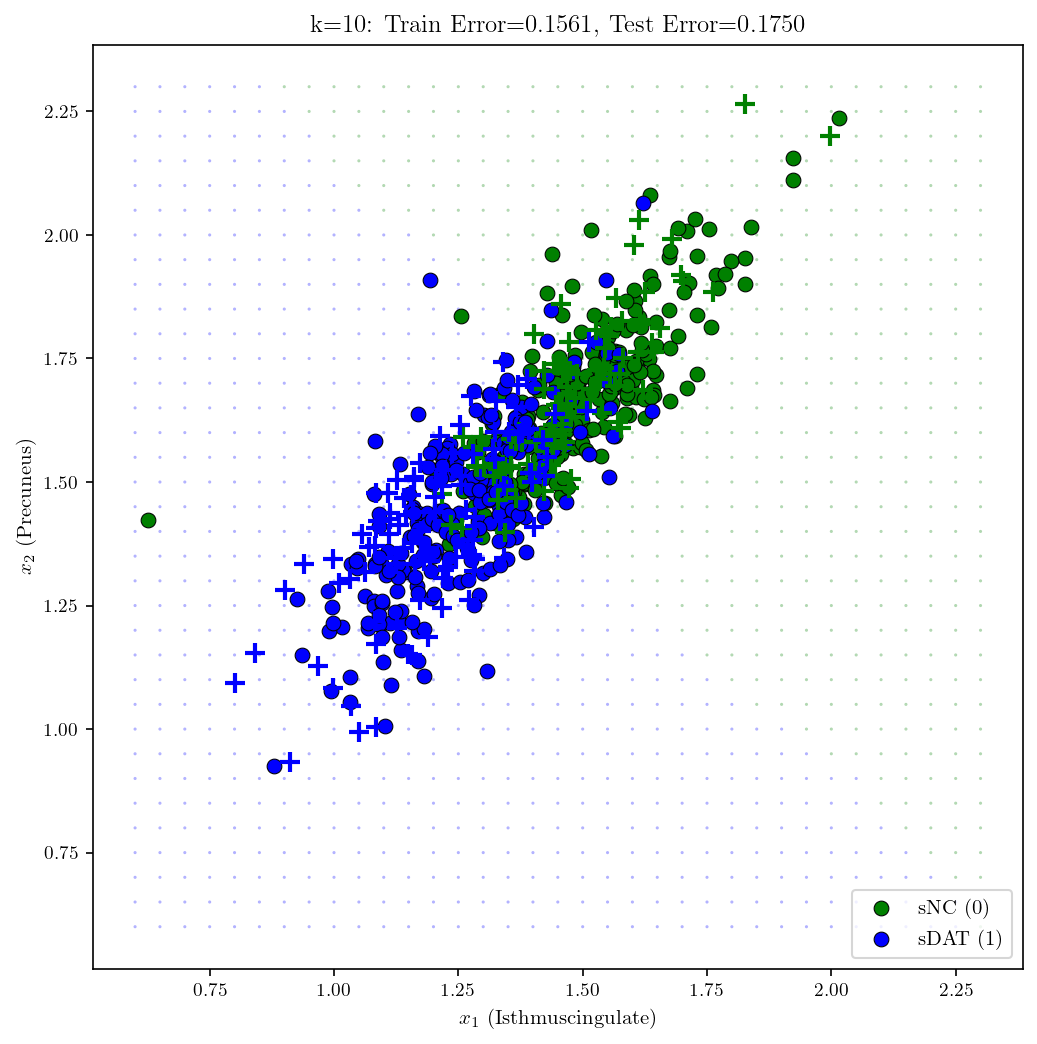

k=20, Train error=0.1688, Test error=0.1700


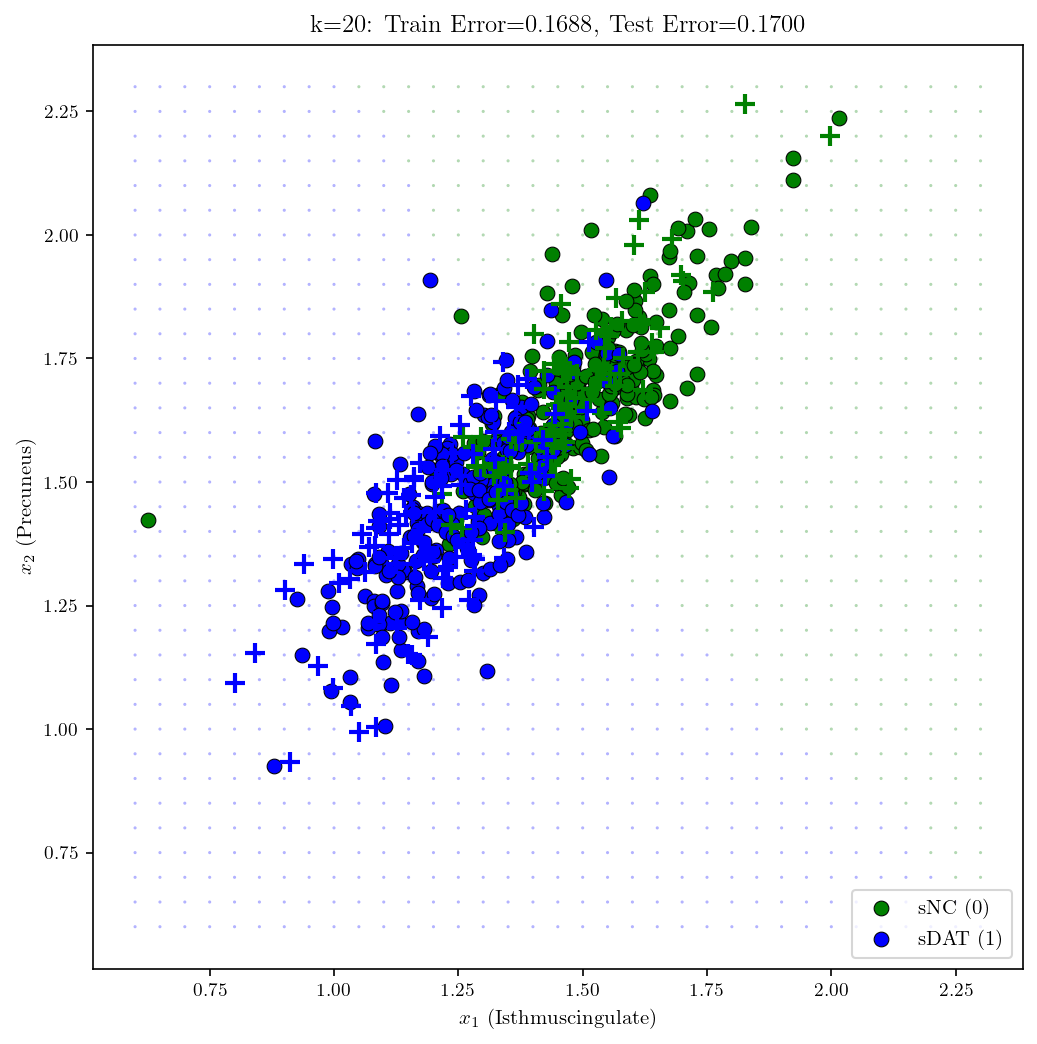

k=30, Train error=0.1709, Test error=0.1550


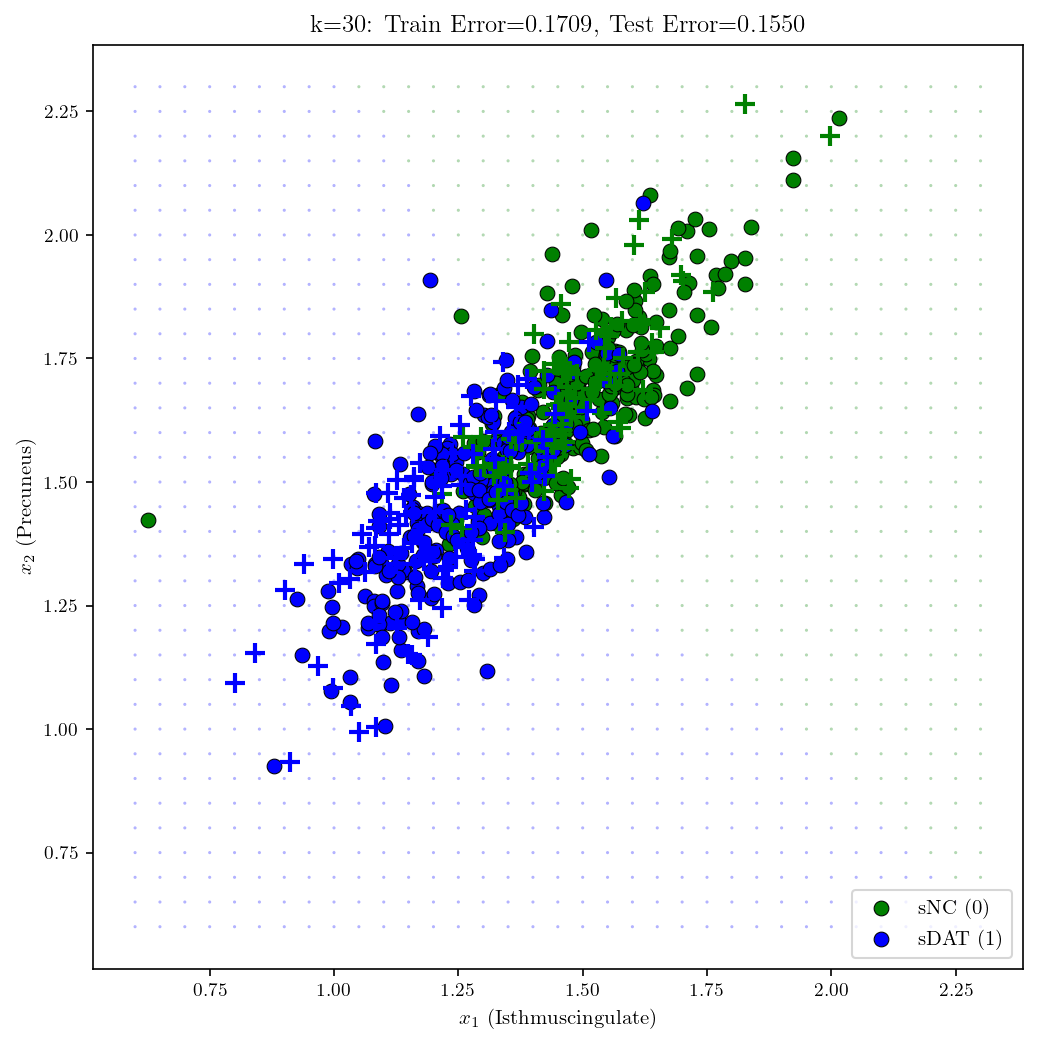

k=50, Train error=0.1667, Test error=0.1900


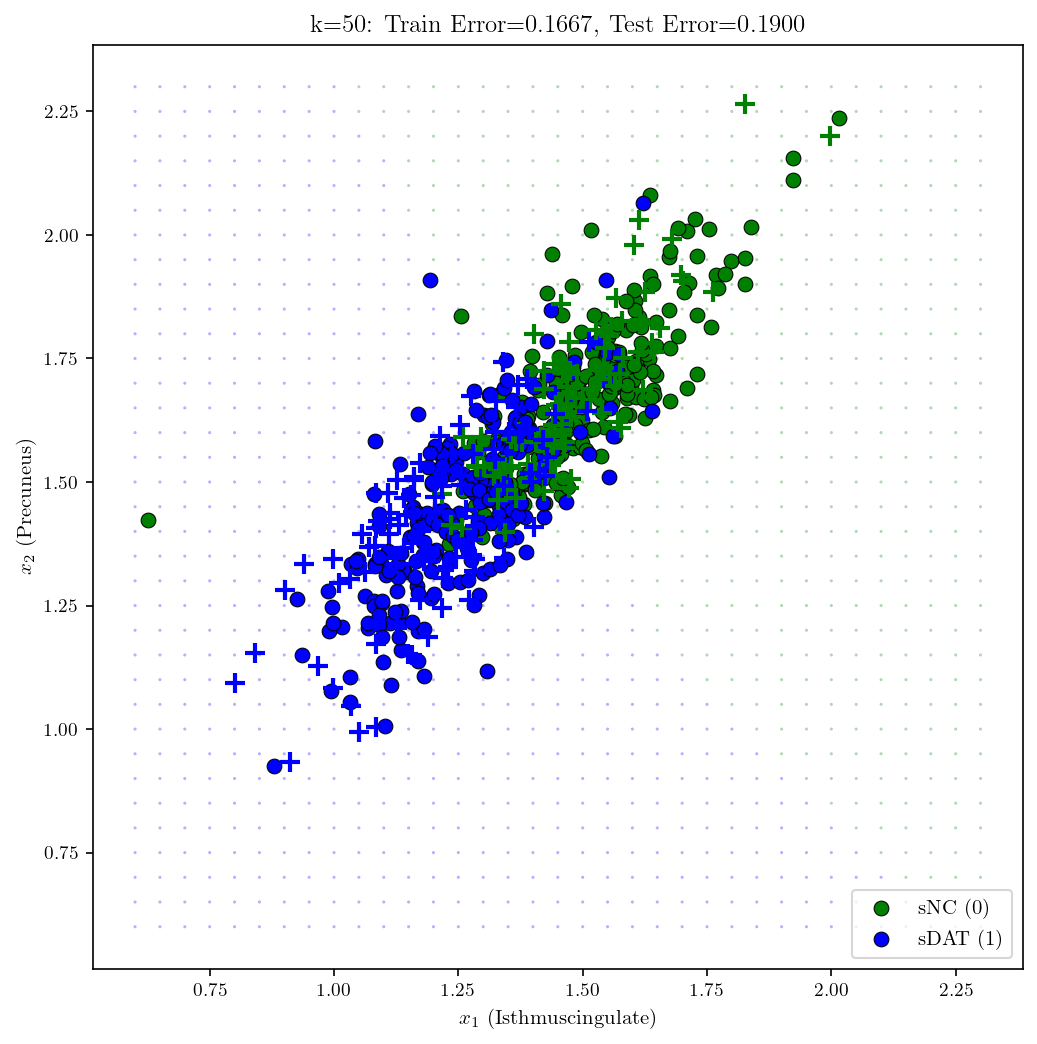

k=100, Train error=0.1962, Test error=0.1950


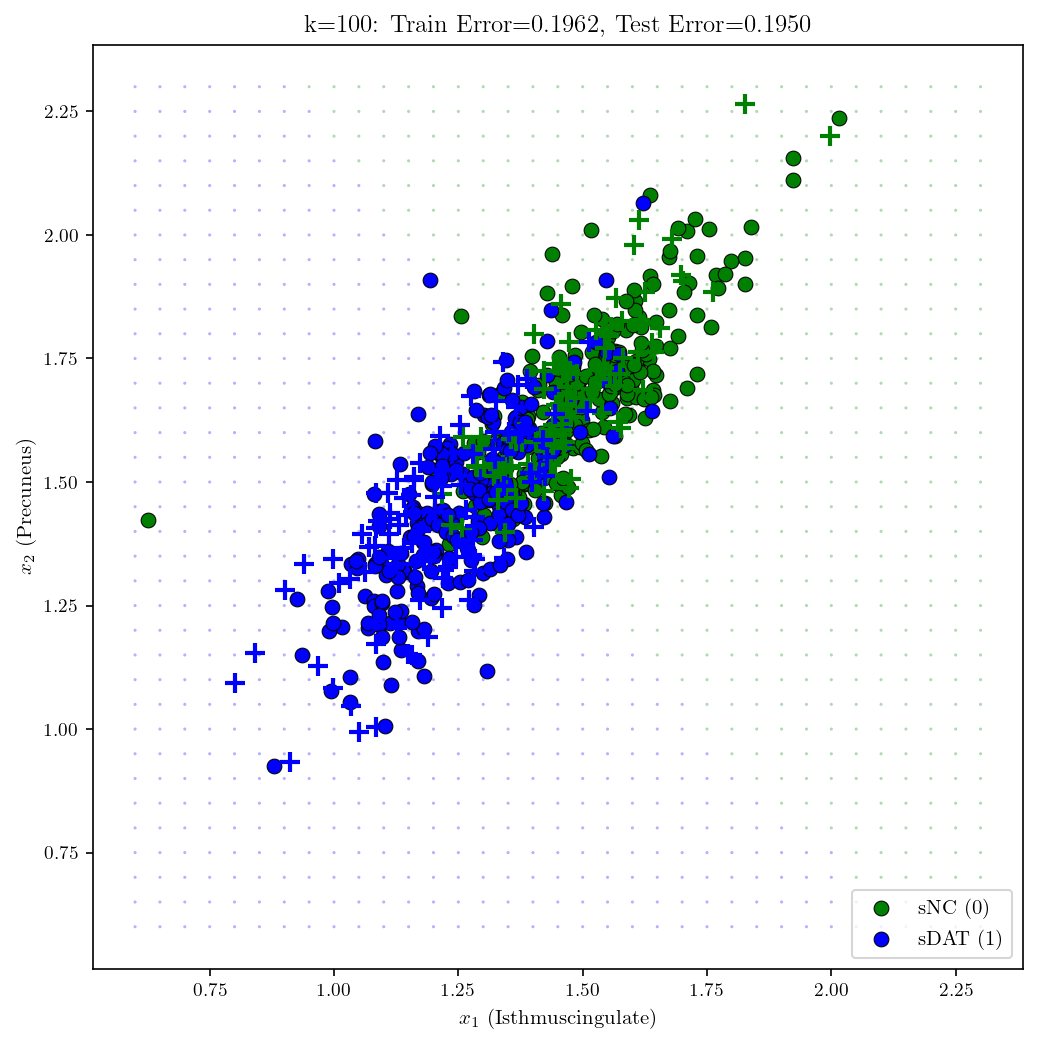

k=150, Train error=0.1920, Test error=0.1900


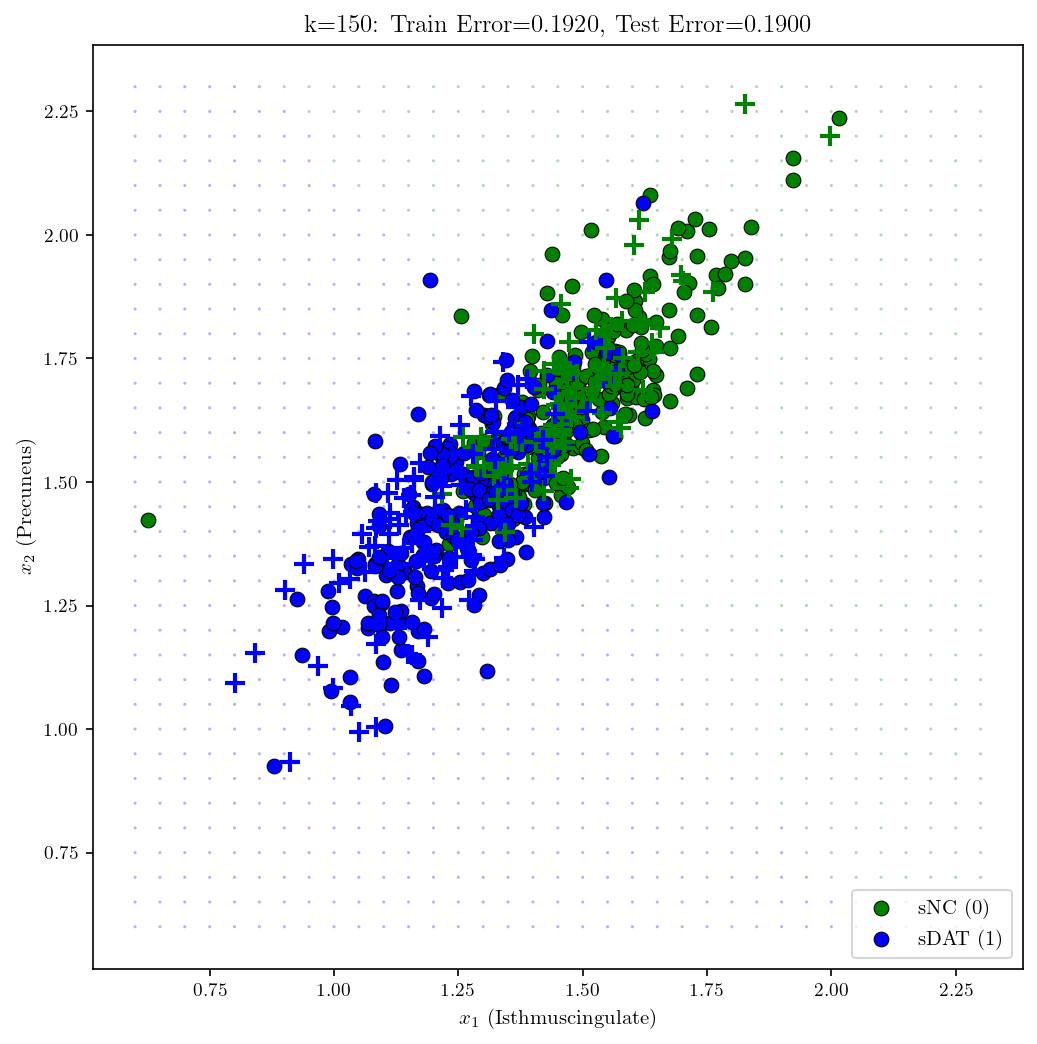

k=200, Train error=0.2152, Test error=0.2050


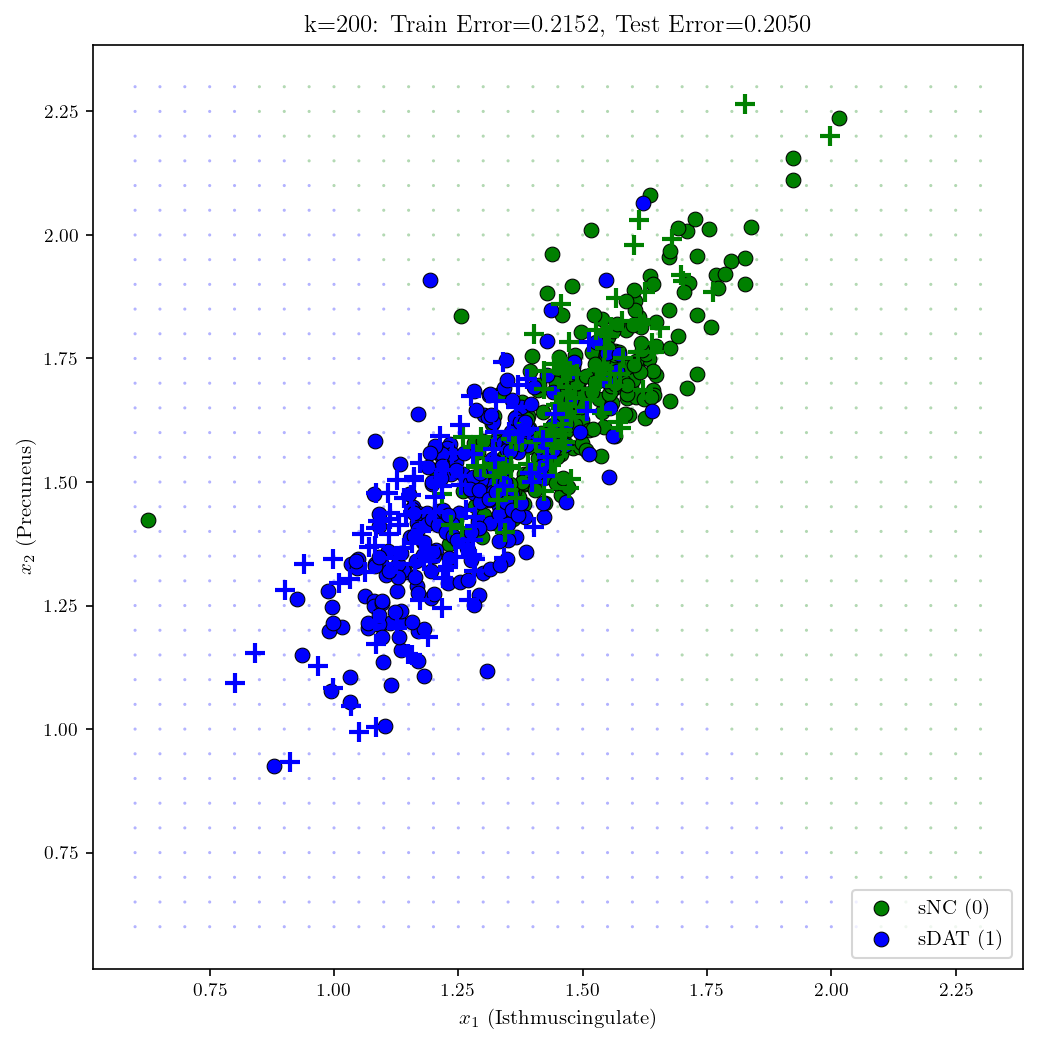

In [141]:
ks = [1, 3, 5, 10, 20, 30, 50, 100, 150, 200]

for k in ks:
    train_knn(k, X_train, y_train, X_test, y_test, grid)

**Overfitting (k=1):**

- Train error = 0% (memorizes training data)
- Test error = 22% (poor generalization)
- Decision boundary too complex (Voronoi tessellation)
- High variance, low bias

**Optimal Range (k=5-30):**

- Best test error at k=30 (16%)
- Balanced bias-variance tradeoff
- Smoother decision boundaries

**Underfitting (k=200):**

- Train error = 22%, Test error = 20.5%
- k=200 ≈ 42% of training data
- Over-smoothed boundary
- High bias, low variance
- Approaching majority class classifier

The error curves show classic bias-variance tradeoff: small k overfits, large k underfits, optimal k balances both.